# WIUT Hackathon 2026 · CV Track — Team WannaCry

Development notebook for our submission. Every session: run **Sections 0–3** (settings, Drive, code, videos; ≈5 min).
Tracks are cached on Drive, so everything after Section 4 also works on a **CPU runtime**.

| Section | What |
|---|---|
| 0–3 | settings, Google Drive, code, sample videos (copied inside Drive, no download) |
| 4 | detection + tracking (GPU, once) → cached tracks on Drive |
| 5 | scene map drawn with the click tool (done once, kept as a record) |
| 6 | our dev labels → `my_labels.json` |
| 7 | rules → events → official `evaluate.py` score |
| 8 | `predictions_samples.json` for the repo |
| 9 | website material: annotated videos, demo test |
| 10 | save + git push |

## 0 · Settings

In [ ]:
TEAM        = "WannaCry"
DRIVE_REL   = "WIUT_CV"
REPO_URL    = "https://github.com/yelmuratov/Traffic-event-detection-CV-WIUT.git"
VIDEO_LINKS = [
    "https://drive.google.com/file/d/1kR9jODA2Wotw4gwkvpRKdqFADNJNc1nS/view?usp=drive_link",
    "https://drive.google.com/file/d/1hp8DYeqtYHSwfM6qAo9FPSRHlpMFrIN_/view?usp=drive_link",
    "https://drive.google.com/file/d/10cHEReCWzO3u-Vk1CnNgHAx6egGy5MwJ/view?usp=drive_link",
    "https://drive.google.com/file/d/1aJ-QsAZVYJtLKHiRvKKeBq1D3GWNobRd/view?usp=drive_link",
]

DRIVE_ROOT    = f"/content/drive/MyDrive/{DRIVE_REL}"
REPO_DIR      = "/content/Traffic-event-detection-CV-WIUT"
LOCAL_SAMPLES = "/content/samples"

## 1 · GPU check

In [ ]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv
!nproc; df -h /content | tail -1

name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07
2
overlay         113G   48G   66G  43% /


## 2 · Google Drive + code

**Code** is cloned from GitHub; for a private repo add a Colab secret `GH_TOKEN` (🔑 icon). The organisers' starter kit
(`run_submission.py`, `evaluate.py`, `examples/`) is already in the repo, unchanged.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
import os
print(os.listdir(DRIVE_ROOT) if os.path.exists(DRIVE_ROOT) else f"{DRIVE_ROOT} will be created in Section 3")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['samples', 'cache', 'labels', 'outputs', 'starter_kit', 'ref_frame.jpg', 'scene_map.json']


**Code.** Preferred: push the repo to GitHub once (P3) and set `REPO_URL`. For a private repo add a Colab secret
`GH_TOKEN` (🔑 icon on the left) with a GitHub token. Until then, upload `wiut-cv.zip` to `My Drive/WIUT_CV/`.

**Starter kit.** Upload the organisers' `run_submission.py`, `evaluate.py` and `examples/` into `My Drive/WIUT_CV/starter_kit/` once;
they are copied into the repo unchanged.

In [ ]:
import os, shutil, subprocess, sys
if not os.path.exists(REPO_DIR):
    if REPO_URL:
        token = ""
        try:
            from google.colab import userdata
            token = userdata.get("GH_TOKEN") or ""
        except Exception:
            pass
        url = REPO_URL.replace("https://", f"https://{token}@") if token else REPO_URL
        subprocess.run(["git", "clone", "-q", url, REPO_DIR], check=True)
    else:
        subprocess.run(["unzip", "-q", "-o", f"{DRIVE_ROOT}/wiut-cv.zip", "-d", "/content"], check=True)

os.environ["WIUT_CACHE"] = f"{DRIVE_ROOT}/cache"  # created in Section 3   # tracks are cached on Drive -> GPU work done once for the team
os.chdir(REPO_DIR); sys.path.insert(0, REPO_DIR)
!pip install -q -r requirements.txt gdown
!bash weights/download.sh

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 8.4 MB/s eta 0:00:00
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 38.7M  100 38.7M    0     0  86.0M      0 --:--:-- --:--:-- --:--:-- 86.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.4M  100 18.4M    0     0  44.9M      0 --:--:-- -

## 3 · Videos: Google Drive link → your Drive → Colab disk (no download)

The four sample videos are ~5–6 GB. Downloading them (browser or `gdown`) is slow and often fails with
*"Too many users have viewed or downloaded this file"*. Instead we:

1. **copy them server-side** with the Drive API (`files.copy`) into `My Drive/WIUT_CV/samples/` — nothing is downloaded, it takes ~1 min per file and happens only once for the team;
2. read them through the Drive mount and **copy to the local SSD** `/content/samples` (fast, ~100–200 MB/s) for random access while decoding;
3. **verify** each file with `ffprobe` (duration should be 5:40, 5:18, 5:18, 2:07).

You will be asked once to allow Colab to access your Google account (needed for the Drive API).

In [ ]:
from tools import colab as cb
drive_paths = cb.import_videos(VIDEO_LINKS, f"{DRIVE_REL}/samples")
VIDEOS = cb.copy_local(drive_paths, LOCAL_SAMPLES)
cb.verify(VIDEOS)
for sub in ["cache", "labels", "outputs", "starter_kit"]:
    os.makedirs(f"{DRIVE_ROOT}/{sub}", exist_ok=True)

✓ C3896.MP4 already in Drive (5.81 GB)
✓ C3897.MP4 already in Drive (5.44 GB)
→ copying C3902.MP4 (5.44 GB) inside Google Drive (no download)...


   copy call returned an error, waiting to see if it lands anyway: <HttpError 403 when requesting https://www.googleapis.com/drive/v3/files/10cHEReCWzO3u-Vk1CnNgHAx6egGy5MwJ/copy?supportsAllDrives=true&fields=id&alt=json returned "The user's Drive storage quota has b
Mounted at /content/drive
   ✗ C3902.MP4 not visible yet. Fallbacks: download_with_gdown(), or open the link → 'Add shortcut to Drive' → put it in My Drive/WIUT_CV/samples
✓ C3905.MP4 already in Drive (2.19 GB)
copying C3896.MP4 to local disk... 44 MB/s
copying C3897.MP4 to local disk... 41 MB/s
copying C3905.MP4 to local disk... 44 MB/s
✓ C3896.mp4                                5:40.3  3840x2160  30000/1001 fps  h264  5.81 GB
✓ C3897.mp4                                5:17.8  3840x2160  30000/1001 fps  h264  5.44 GB
✓ C3905.mp4                                2:07.6  3840x2160  30000/1001 fps  h264  2.19 GB


In [ ]:
import io, os, glob, time
from googleapiclient.http import MediaIoBaseDownload

svc = cb.drive_service()
fid = cb.file_id(VIDEO_LINKS[2])                      # the missing video (C3902)
meta = svc.files().get(fileId=fid, fields="name,size", supportsAllDrives=True).execute()
dst = f"{LOCAL_SAMPLES}/{os.path.splitext(meta['name'])[0]}.mp4"
if not (os.path.exists(dst) and os.path.getsize(dst) == int(meta["size"])):
    t0 = time.time()
    with io.FileIO(dst, "wb") as fh:
        dl = MediaIoBaseDownload(fh, svc.files().get_media(fileId=fid, supportsAllDrives=True), chunksize=256 * 2**20)
        done = False
        while not done:
            status, done = dl.next_chunk()
            print(f"\r{meta['name']}: {status.progress()*100:5.1f}%", end="")
    print(f"  done in {time.time()-t0:.0f}s")

for p in glob.glob(f"{LOCAL_SAMPLES}/*.MP4"):
    os.rename(p, p[:-4] + ".mp4")
VIDEOS = sorted(glob.glob(f"{LOCAL_SAMPLES}/*.mp4"))
cb.verify(VIDEOS)

C3902.MP4: 100.0%  done in 158s
✓ C3896.mp4                                5:40.3  3840x2160  30000/1001 fps  h264  5.81 GB
✓ C3897.mp4                                5:17.8  3840x2160  30000/1001 fps  h264  5.44 GB
✓ C3902.mp4                                5:17.8  3840x2160  30000/1001 fps  h264  5.44 GB
✓ C3905.mp4                                2:07.6  3840x2160  30000/1001 fps  h264  2.19 GB


In [ ]:
!ls /content/drive/MyDrive
!ls /content/drive/MyDrive/WIUT_CV
!grep -c stop_1 scene/scene_map.json

 1000013892.pdf
'1000014947 (2).pdf'
'1000015330 (3).pdf'
'12 week in a year.gsheet'
 1mavzu.gslides
'2025-11-24 21-49-16.mp4'
'2nd lesson.gdoc'
'2_Perception-Driven Agricultural Robotics.gdoc'
'350969_Psixologiya fan sifatida. M1.doc.gdoc'
'351056_Psixologiya maktablari. M6.doc.gdoc'
 351150_Psixolog_kasbiy_faoliyati_va_psixologiya_metodlari_M16_doc.gdoc
'3rd lesson.gdoc'
 7_тема_Значение_исламских_ценностей_и_просвещения_в_современном.gslides
 8_тема_Новые_религиозные_учения_и_секты.gslides
 9_тема_Религия_в_киберпространстве.gslides
 Action_Log_Description.gdoc
 Action_Log.gsheet
 algorithms.gdoc
 Amaliyotchi_psixologning_maxsus_qobiliyatlari.gdoc
'Application Development - Doniyor Yuldashev.gdoc'
'Application Programming Interface - Doniyor Yuldashev.gdoc'
 Assignment-1_Doniyor_Yuldashev.gdoc
'ASSIGNMENT (1).gdoc'
'Assignment 2 Doniyor Yuldashev 600002695.gdoc'
'Assignment2_Linear Regression.gdoc'
 Assignment-3_Doniyor_Yuldashev.gdoc
'Assignment 4 Doniyor Yuldashev.gdoc'
'Assignme

In [ ]:
!ls scene

ref_frame.jpg  scene_map.json


In [ ]:
# Imports used by all sections below (run this even if you skip to your own section)
import os, glob, json, time, logging, shutil
import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt
from src import config
from src.video import probe, read_frame_at
from src.scene import load_scene
from src.tracker import analyse_video
logging.getLogger("wiut").setLevel(logging.INFO)
print("device:", config.DEVICE)

device: 0


## 4 · Detection + tracking (GPU, once)

One decoding pass per video: PyAV reference frames (≈ every 3rd frame) → YOLO11m @1280 → ByteTrack.
Results are cached in `WIUT_CV/cache/`, so this only re-runs if `config.DETECTOR` / `config.TRACKER` change.
A cached video shows ~0 s.

In [ ]:
speed = []
for p in VIDEOS:
    m = probe(p); t0 = time.time()
    tracks, _ = analyse_video(m, load_scene(m.width, m.height, video_path=p), progress=True)
    dt = time.time() - t0
    speed.append({"video": m.name, "rows": len(tracks), "tracks": len(set(tracks[:, 2])) if len(tracks) else 0,
                  "seconds": round(dt, 1), "x_realtime": round(dt / m.duration, 2)})
display(pd.DataFrame(speed))   # a cached video shows ~0 s

device: 0 | detector: {'weights': 'yolo11m.pt', 'imgsz': 1280, 'conf': 0.25, 'iou': 0.6, 'decoder': 'pyav_ref', 'stride': 3, 'batch': 8, 'max_width': 1920}


,video,rows,tracks,seconds,x_realtime
0,C3896.mp4,158094,1242,0.5,0.0
1,C3897.mp4,151647,1103,0.4,0.0
2,C3902.mp4,179688,1728,0.4,0.0
3,C3905.mp4,69473,782,0.2,0.0


**Done once — do not re-run.** The result is `scene/scene_map.json` in the repo; these cells are kept as a record of how it was made.

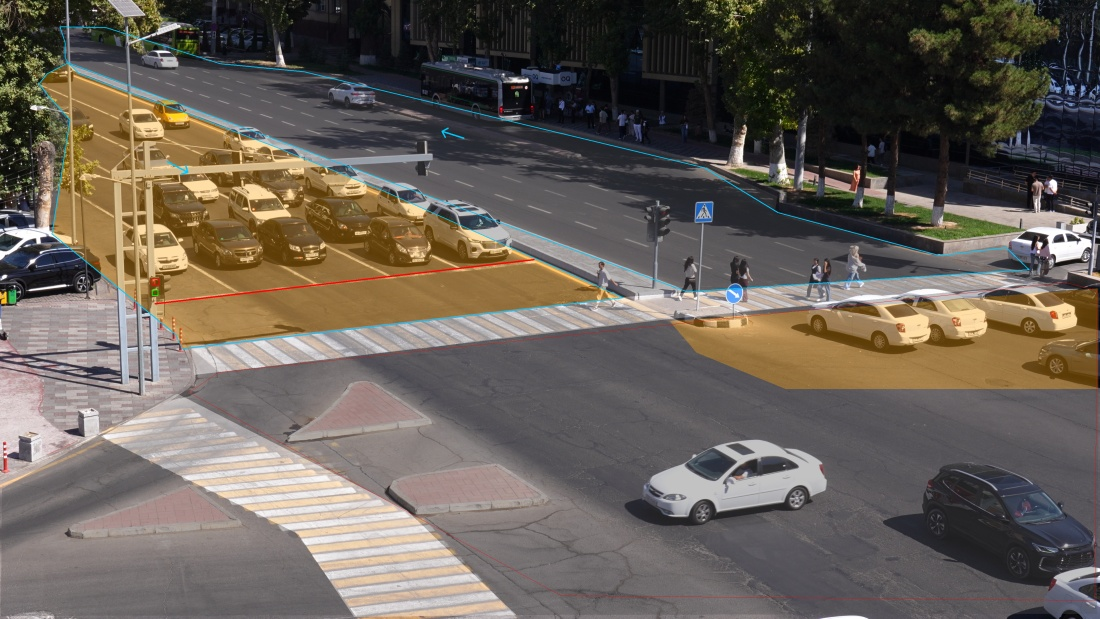

In [ ]:
import json
from src.scene import Scene, EMPTY_SCENE
from src.video import probe, read_frame_at
REF_VIDEO, REF_T = VIDEOS[0], 10.0
ref = read_frame_at(REF_VIDEO, REF_T)
scene = json.load(open(config.SCENE_PATH)) if os.path.exists(config.SCENE_PATH) else dict(EMPTY_SCENE)
for k, v in EMPTY_SCENE.items(): scene.setdefault(k, v if not isinstance(v, (list, dict)) else type(v)())
scene["size"] = [ref.shape[1], ref.shape[0]]

def save_scene(show=True):
    json.dump(scene, open(config.SCENE_PATH, "w"), indent=1)
    shutil.copy(config.SCENE_PATH, f"{DRIVE_ROOT}/scene_map.json")
    if show: cb.show(Scene(scene, ref.shape[1], ref.shape[0]).draw(ref))

def undo(key):
    if scene[key]: scene[key].pop(); save_scene()

save_scene()

<IPython.core.display.Javascript object>

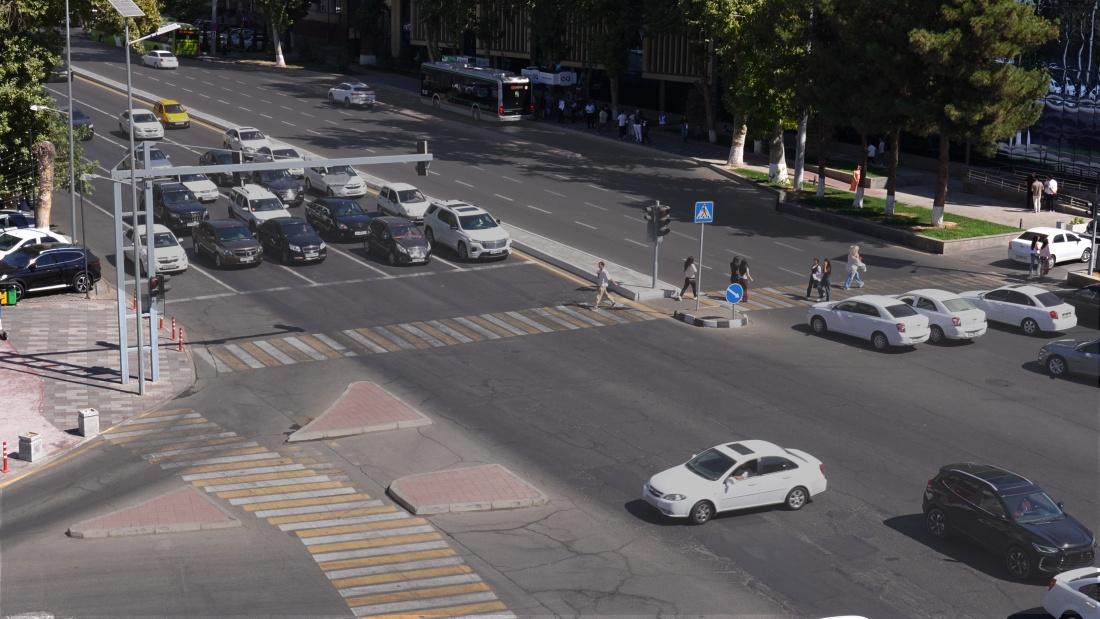

In [ ]:
# Carriageway (road surface only - NOT sidewalks). Several polygons allowed.
scene["road"].append(cb.pick(ref, "Road / carriageway polygon")); save_scene()

<IPython.core.display.Javascript object>

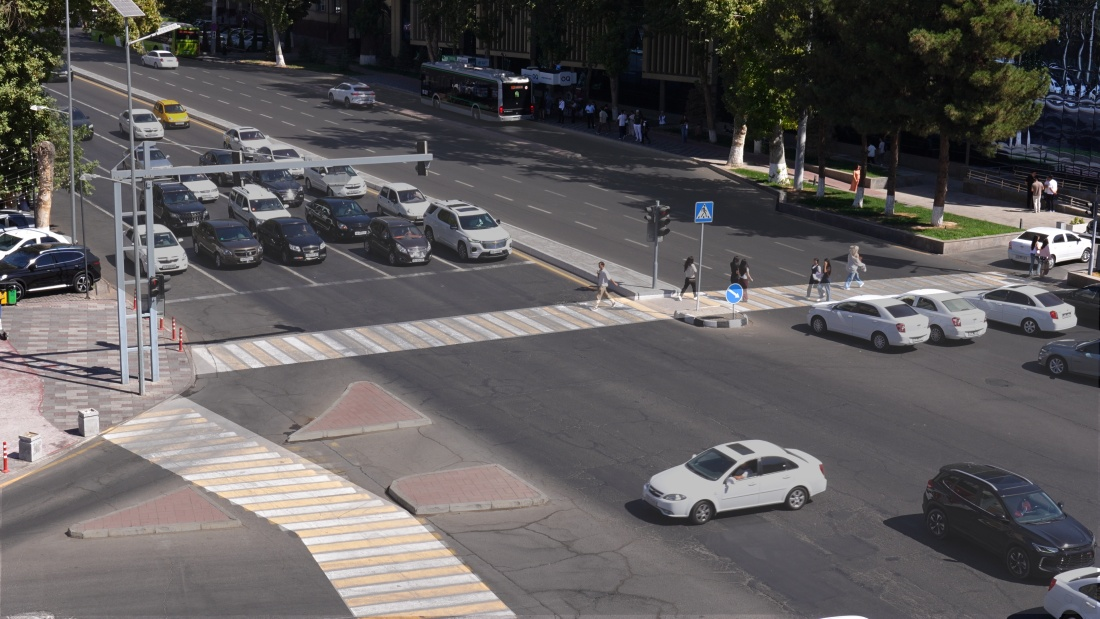

In [ ]:
# Pedestrian crossings (zebra)
scene["crosswalks"].append(cb.pick(ref, "Crosswalk polygon")); save_scene()

In [ ]:
import pandas as pd
from src.video import probe
from src.tracks import build_table
from src.scene import Poly
ALL = pd.concat([build_table(analyse_video(probe(p), None)[0], probe(p).fps) for p in VIDEOS])

def auto_dir(poly):
    mv = ALL[(ALL.speed_n > 1.0) & ALL.cls.isin([2, 3, 5, 7])]
    inside = Poly(poly).contains(mv.gx.values, mv.gy.values)
    v = mv[["vx", "vy"]].values[inside]
    u = v / np.linalg.norm(v, axis=1, keepdims=True)
    mean = u.mean(0); coh = np.linalg.norm(mean)
    print(f"{inside.sum()} moving-car samples, agreement {coh:.2f}  (close to 1.0 = one-way)")
    return (mean / coh).round(4).tolist()
print("ready")

ready


<IPython.core.display.Javascript object>

33847 moving-car samples, agreement 0.68  (close to 1.0 = one-way)


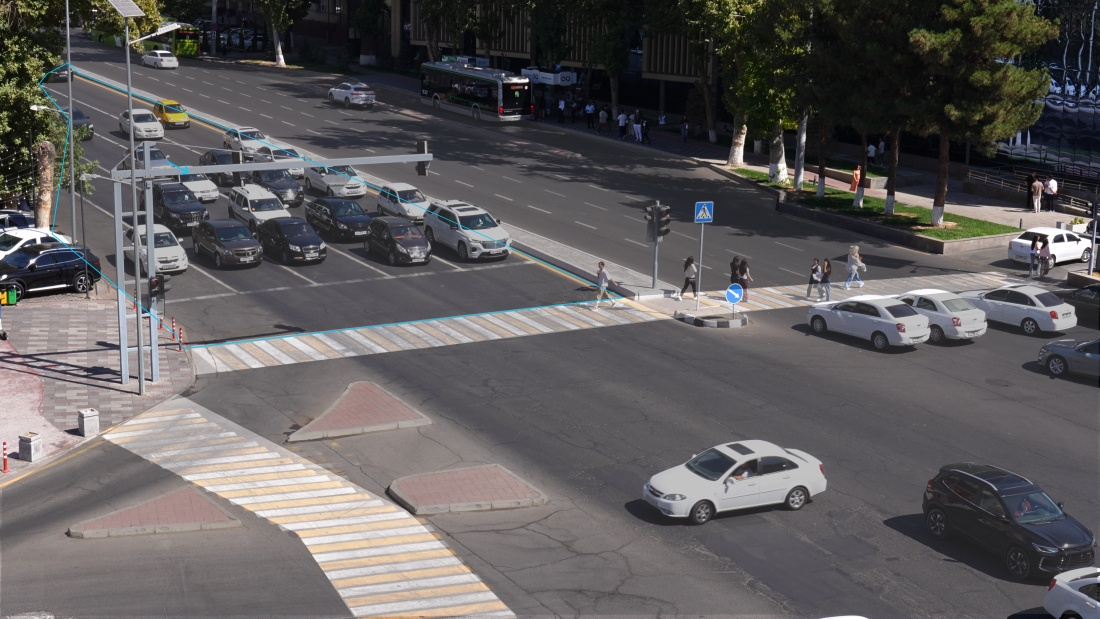

In [ ]:
poly = cb.pick(ref, "Lane 1: lower carriageway (green, a1-a7)")
scene["lanes"].append({"name": "lane_1", "polygon": poly, "direction": auto_dir(poly), "group": "dir_A"})
save_scene()

<IPython.core.display.Javascript object>

57215 moving-car samples, agreement 1.00  (close to 1.0 = one-way)


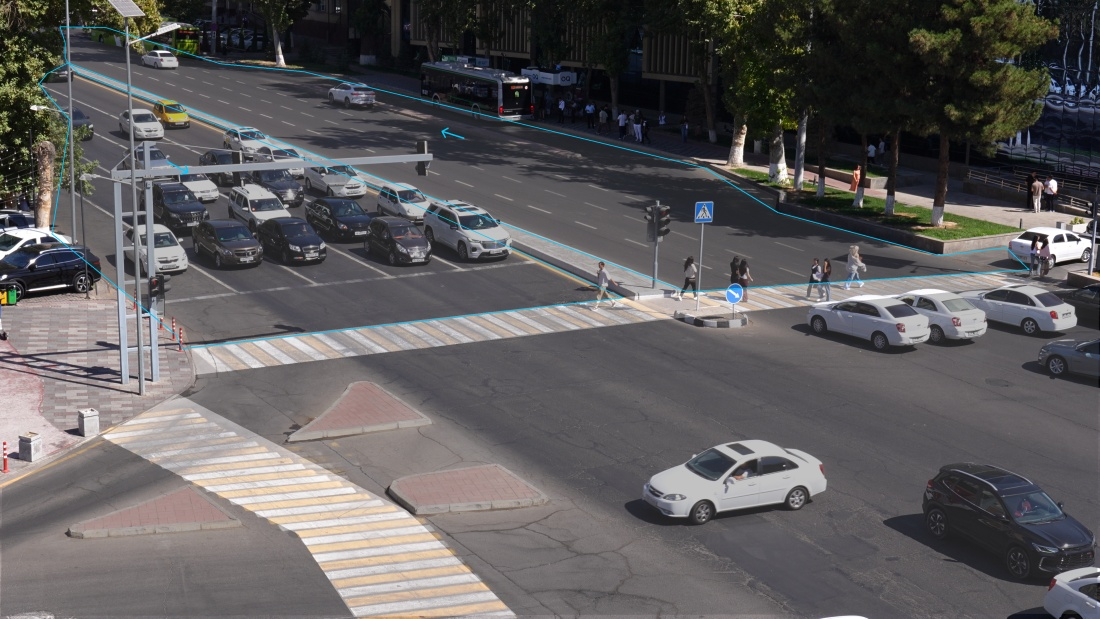

In [ ]:
poly = cb.pick(ref, "Lane 2: upper carriageway (orange, b1-b8)")
scene["lanes"].append({"name": "lane_2", "polygon": poly, "direction": auto_dir(poly), "group": "dir_B"})
save_scene()

In [ ]:
print(len(scene["lanes"]), "lanes")
for l in scene["lanes"]:
    print(l["name"], l["direction"])

2 lanes
lane_1 [0.8859, 0.4638]
lane_2 [-0.9542, -0.2992]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

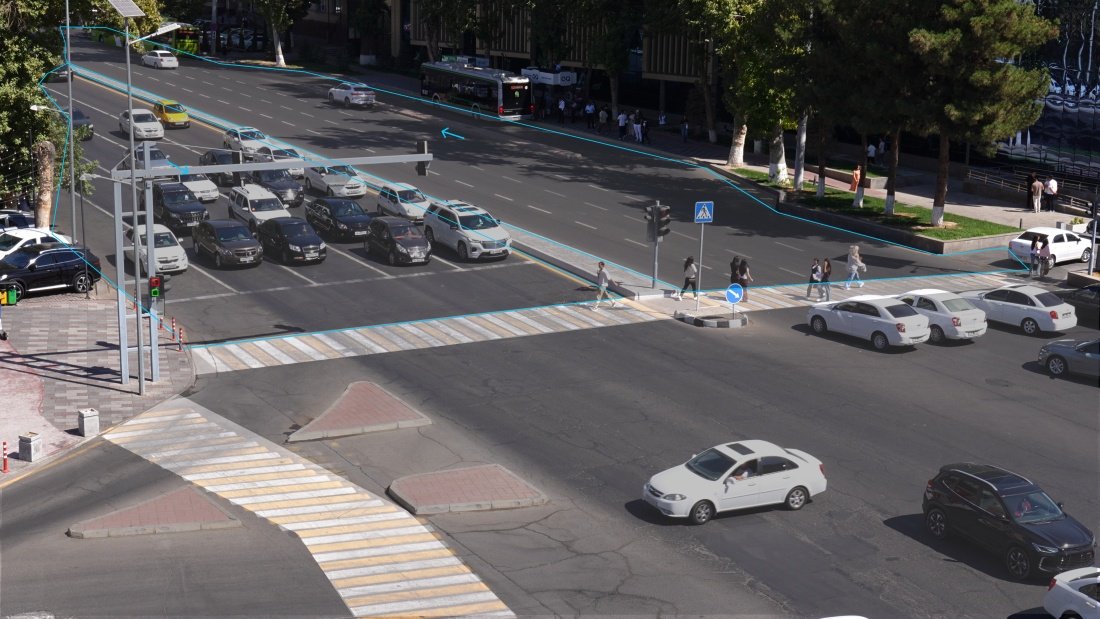

In [ ]:
# Traffic light: first a box around the whole light (zoom), then the RED and GREEN lamp boxes inside the zoom.
SIGNAL = "sig_1"
zoom  = cb.box_from(cb.pick(ref, "Box around the traffic light (for zoom)", "box"))
red   = cb.box_from(cb.pick(ref, "RED lamp", "box", crop=zoom))
green = cb.box_from(cb.pick(ref, "GREEN lamp", "box", crop=zoom))
scene["signals"][SIGNAL] = {"red_roi": red, "green_roi": green}; save_scene()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

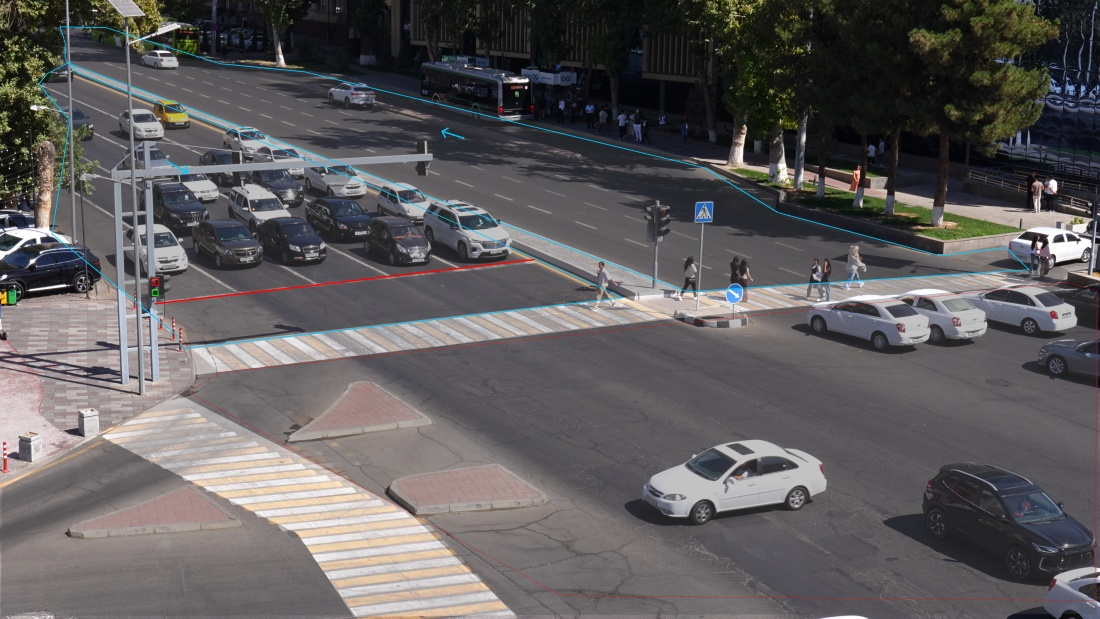

In [ ]:
line  = cb.pick(ref, "Stop line: click S1, then S2", "line")
inter = cb.pick(ref, "Intersection area: I1 to I6")
scene["stop_lines"] = [{"name": "stop_1", "line": line, "direction": scene["lanes"][0]["direction"],
                        "signal": "sig_1", "intersection": inter}]
save_scene()

<IPython.core.display.Javascript object>

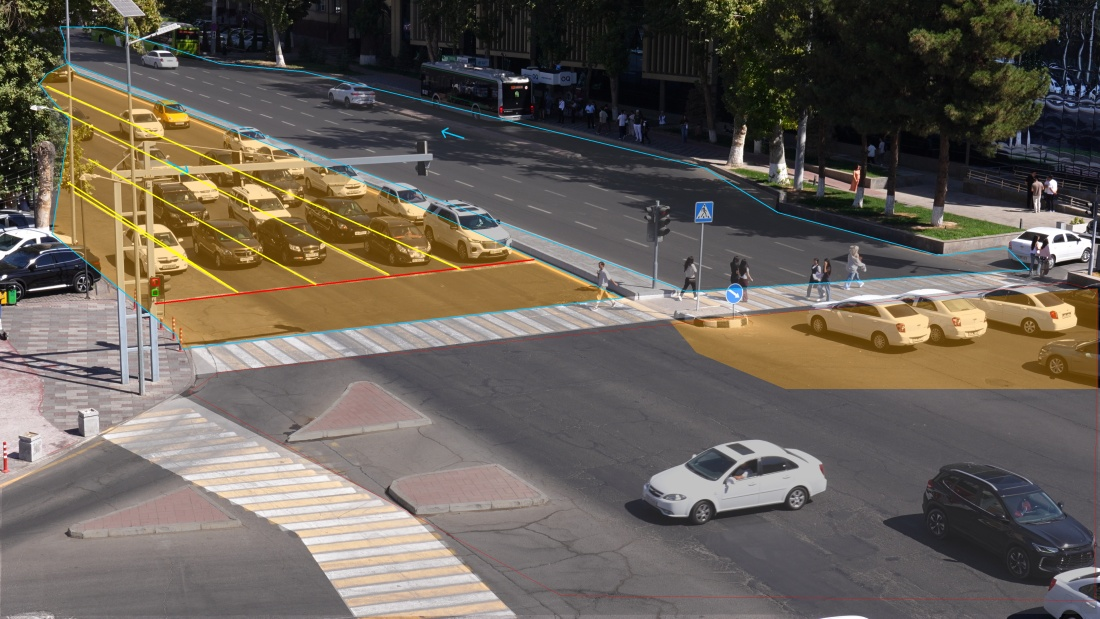

5 solid lines saved


In [ ]:
# Solid lane markings: run once per solid line, click along it (2-5 points), then Done
scene["solid_lines"].append(cb.pick(ref, f"Solid line #{len(scene['solid_lines']) + 1}: click along it", "polyline"))
save_scene()
print(len(scene["solid_lines"]), "solid lines saved")

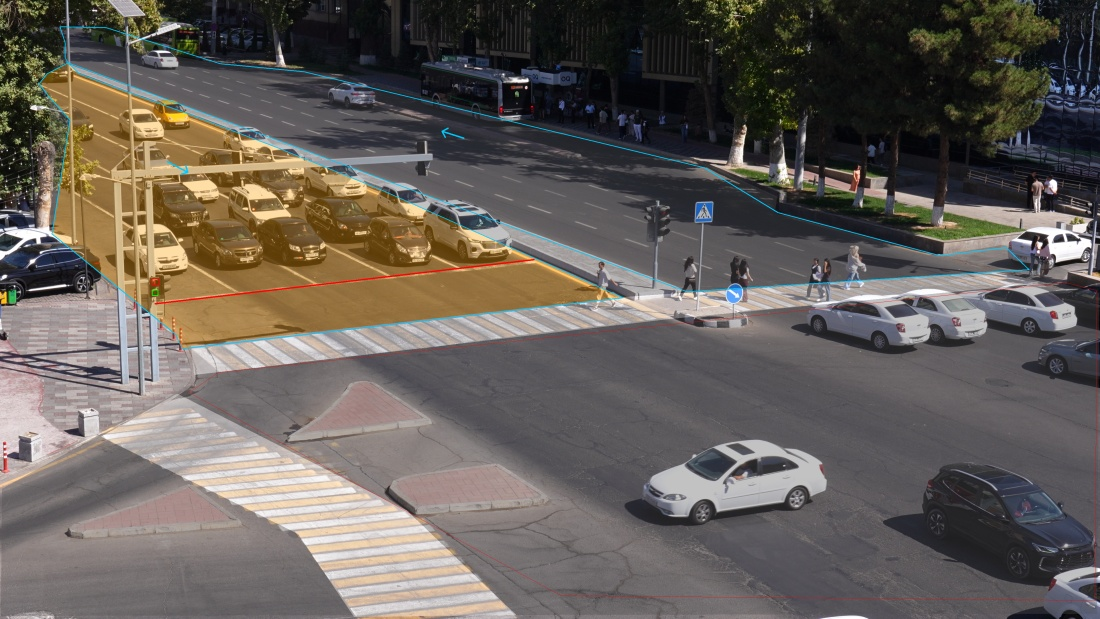

2 lanes | 2 crosswalks | ['sig_1'] | stop lines: 1


In [ ]:
scene["queue_zones"] = [scene["lanes"][0]["polygon"]]
save_scene()
print(len(scene["lanes"]), "lanes |", len(scene["crosswalks"]), "crosswalks |",
      list(scene["signals"]), "| stop lines:", len(scene["stop_lines"]))

In [ ]:
# Forbidden movement: vehicle goes from zone A to zone B where that turn is prohibited (use signs/markings in camera.md)
frm = cb.pick(ref, "Forbidden movement: ENTRY zone")
to  = cb.pick(ref, "Forbidden movement: EXIT zone")
scene["forbidden_movements"].append({"name": f"move_{len(scene['forbidden_movements'])+1}", "from": frm, "to": to,
                                     "label": "illegal_turn"})   # or "illegal_u_turn"
save_scene()

**Check the traffic-light reader** — the state should flip red/green in a regular cycle. If it is mostly `-1` (unknown), redraw the lamp boxes tighter.

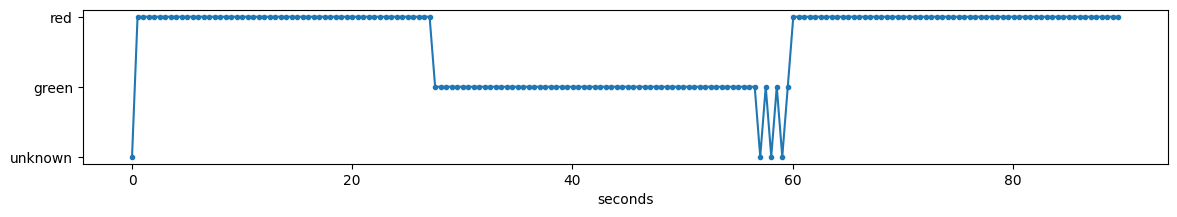

In [ ]:
import cv2, matplotlib.pyplot as plt
from src.scene import signal_state
sig = load_scene(3840, 2160).signals["sig_1"]
cap = cv2.VideoCapture(VIDEOS[0]); ts, st, i = [], [], 0
while i < 90 * 30:                       # first 90 seconds
    if not cap.grab(): break
    if i % 15 == 0:                      # 2 checks per second
        _, f = cap.retrieve(); ts.append(i / 29.97); st.append(signal_state(f, sig))
    i += 1
plt.figure(figsize=(14, 2)); plt.plot(ts, st, ".-")
plt.yticks([-1, 0, 1], ["unknown", "green", "red"]); plt.xlabel("seconds"); plt.show()

## 6 · Labels (everyone) — our dev set

Follow the start/end conventions in the task PDF exactly —
at tIoU 0.7 a boundary that is 1 s off on a 5 s event already fails.
Edit your file `WIUT_CV/labels/labels_<you>.json` (double-click it in the Colab file browser, or edit on your laptop):
`[start_sec, end_sec, "label"]` in each video's `events` list.

In [ ]:
# Watch a short window with the timestamp burned in to set exact boundaries
cb.play_clip(VIDEOS[0], t0=10.0, t1=20.0)

In [ ]:
!git pull
from tools.labels import from_txt, check, summary
labels = from_txt("labels/labels.txt", LOCAL_SAMPLES)
print(check(labels) or "labels OK", summary(labels))
json.dump(labels, open("my_labels.json", "w"), indent=1)

Already up to date.
labels OK {'jaywalking': 22, 'solid_line_crossing': 13, 'failure_to_yield': 13, 'congestion': 9, 'illegal_turn': 8, 'stop_line': 4, 'stopped_vehicle': 4, 'red_light': 2, 'illegal_u_turn': 1, 'near_miss': 1}


## 7 · rules → events → score (fast loop)

Tracks come from the cache, so one iteration over all videos takes seconds. Tune thresholds in `src/config.py`
(open it in the Colab file browser), then re-run this cell. Classes that never score well on our labels should be switched off in `config.ENABLED`.

In [ ]:
import importlib
import pandas as pd

def reload_all():
    import src.config, src.utils, src.video, src.scene, src.tracker, src.tracks, src.rules, src.postprocess, src.pipeline, src.risk
    for mod in [src.config, src.utils, src.video, src.scene, src.tracker, src.tracks, src.rules, src.postprocess, src.pipeline, src.risk]:
        importlib.reload(mod)
reload_all()
from src.pipeline import detect_events

preds, DEBUG = {"team": TEAM, "videos": {}}, {}
for p in VIDEOS:
    m = probe(p)
    ev, raw, ctx = detect_events(p, return_raw=True)
    DEBUG[m.name] = (raw, ctx)
    preds["videos"][m.name] = {"events": ev, "risk": [[round(i / m.fps, 3), 0.0] for i in range(m.n_frames)]}
    print(f"{m.name}: {len(ev)} events", pd.Series([e[2] for e in ev]).value_counts().to_dict())
json.dump(preds, open("/content/pred_rules_only.json", "w"))
!python evaluate.py --pred /content/pred_rules_only.json --validate-only
if os.path.exists("my_labels.json"):
    !python evaluate.py --pred /content/pred_rules_only.json --gt my_labels.json --per-video

INFO:wiut.scene:C3896.mp4: scene alignment 904 inliers, max shift 5.8 px
INFO:wiut.pipeline:C3896.mp4: 18 events (42 raw) in 30.0s


C3896.mp4: 18 events {'failure_to_yield': 4, 'jaywalking': 4, 'illegal_turn': 3, 'congestion': 2, 'red_light': 2, 'solid_line_crossing': 2, 'stop_line': 1}


INFO:wiut.scene:C3897.mp4: scene alignment 1140 inliers, max shift 5.9 px
INFO:wiut.pipeline:C3897.mp4: 26 events (65 raw) in 29.3s


C3897.mp4: 26 events {'jaywalking': 9, 'solid_line_crossing': 5, 'failure_to_yield': 5, 'stopped_vehicle': 4, 'stop_line': 2, 'illegal_turn': 1}


INFO:wiut.scene:C3902.mp4: scene alignment 78 inliers, max shift 131.9 px
INFO:wiut.pipeline:C3902.mp4: 20 events (47 raw) in 31.4s


C3902.mp4: 20 events {'jaywalking': 7, 'failure_to_yield': 5, 'stopped_vehicle': 3, 'solid_line_crossing': 3, 'illegal_turn': 1, 'stop_line': 1}


INFO:wiut.scene:C3905.mp4: scene alignment 94 inliers, max shift 75.5 px
INFO:wiut.pipeline:C3905.mp4: 12 events (31 raw) in 23.3s


C3905.mp4: 12 events {'jaywalking': 4, 'failure_to_yield': 3, 'solid_line_crossing': 2, 'stopped_vehicle': 1, 'stop_line': 1, 'congestion': 1}
python3: can't open file '/content/Traffic-event-detection-CV-WIUT/evaluate.py': [Errno 2] No such file or directory
python3: can't open file '/content/Traffic-event-detection-CV-WIUT/evaluate.py': [Errno 2] No such file or directory


In [ ]:
!ls -R /content/drive/MyDrive/WIUT_CV/starter_kit | head -50

/content/drive/MyDrive/WIUT_CV/starter_kit:


In [ ]:
   !sed -i 's/"road_obstacle": True/"road_obstacle": False/' src/config.py

In [ ]:
   !git checkout -- src/config.py && git pull

remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.55 KiB | 795.00 KiB/s, done.
From https://github.com/yelmuratov/Traffic-event-detection-CV-WIUT
   4cd5dec..40cc203  main       -> origin/main
Updating 4cd5dec..40cc203
Fast-forward
 src/config.py  |  2 +-
 tools/score.py | 62 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 63 insertions(+), 1 deletion(-)
 create mode 100644 tools/score.py


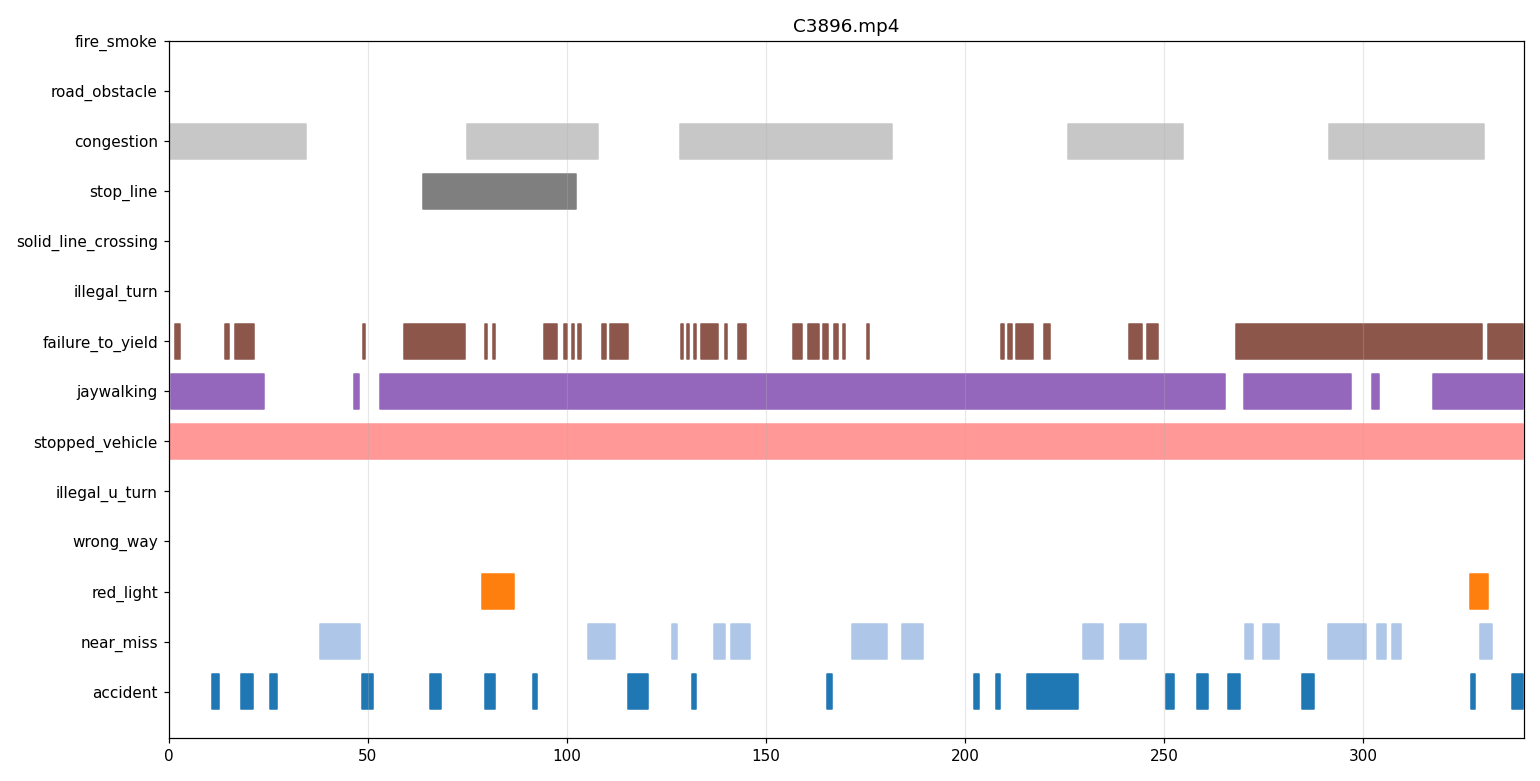

In [ ]:
# Inspect one video: predicted vs labelled events on a timeline
from tools.render import timeline_png
from IPython.display import Image
name = os.path.basename(VIDEOS[0])
gt = json.load(open("my_labels.json")).get(name, {}).get("events") if os.path.exists("my_labels.json") else None
timeline_png(preds["videos"][name]["events"], probe(VIDEOS[0]).duration, "/content/tl.png", gt=gt, title=name)
display(Image("/content/tl.png"))

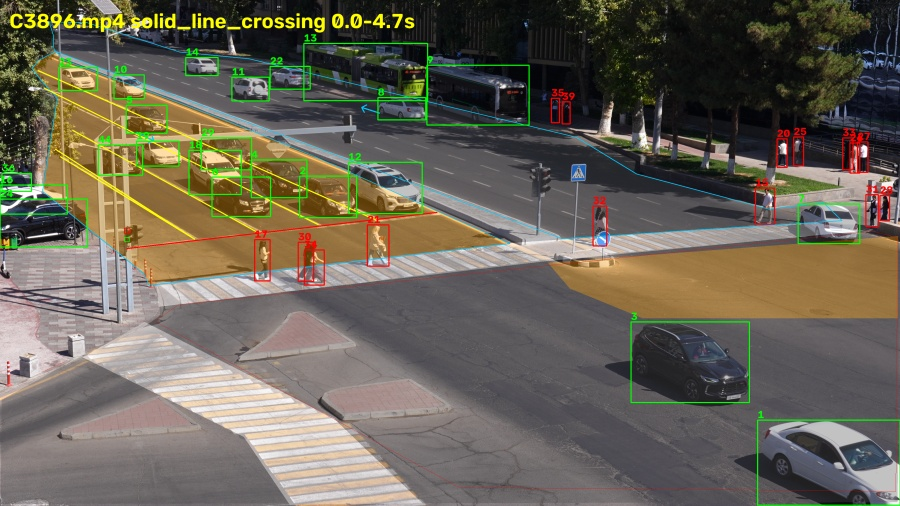

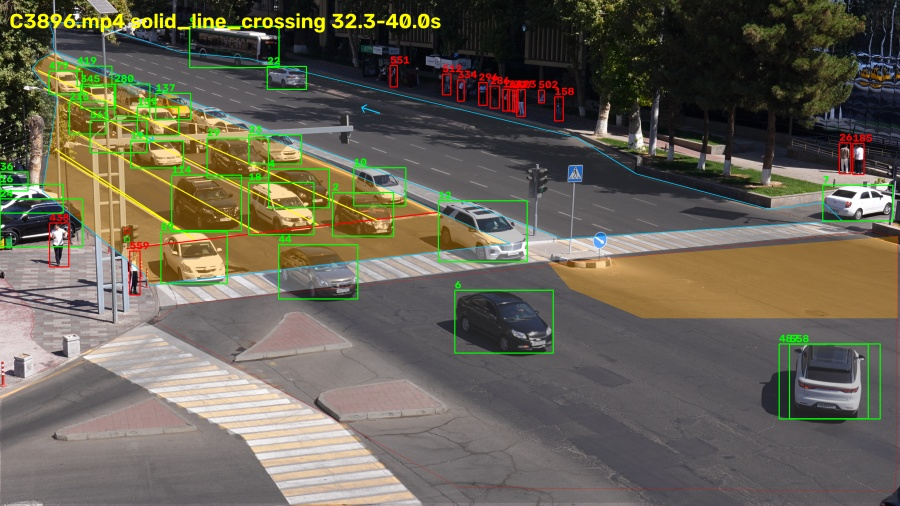

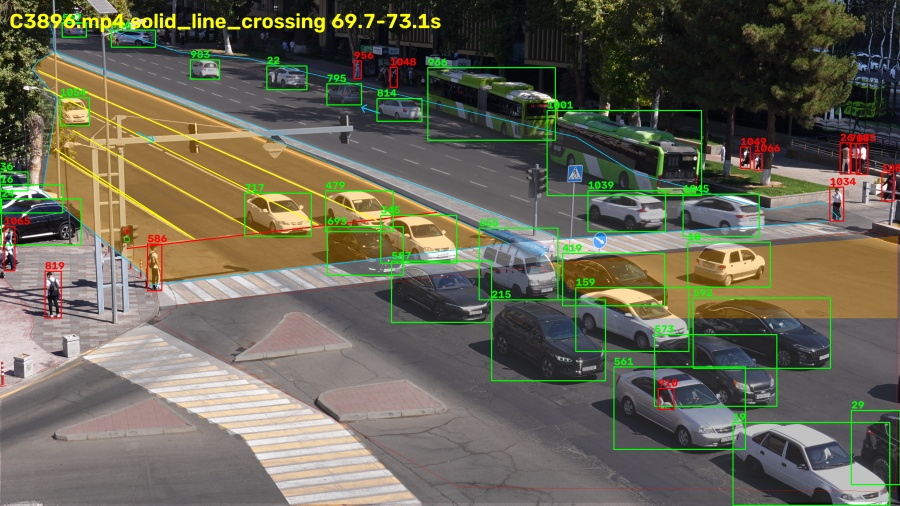

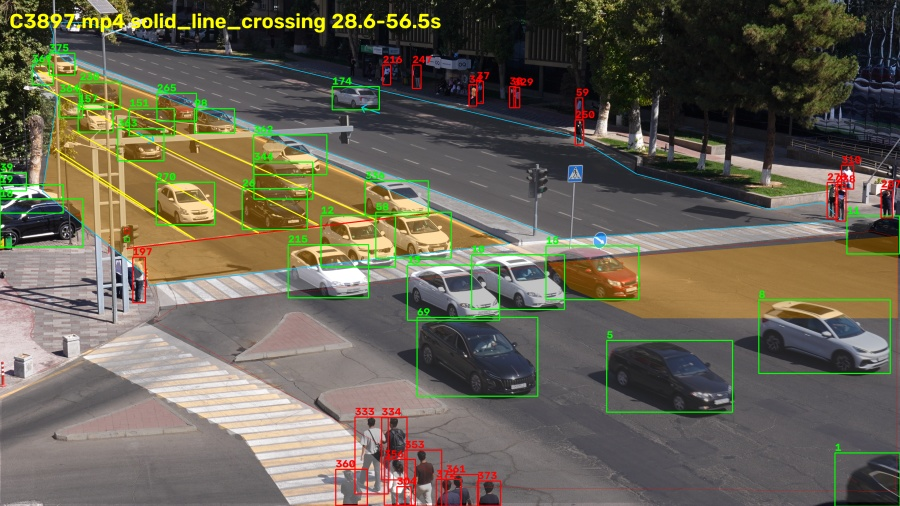

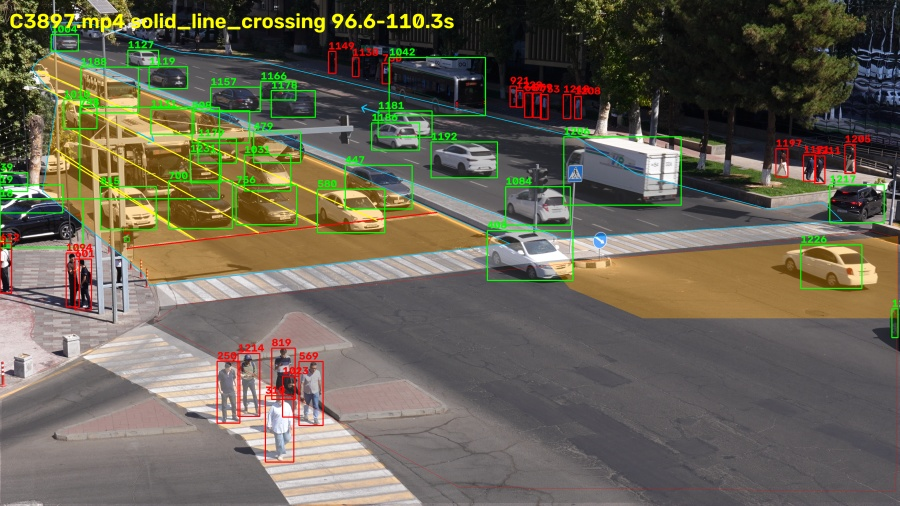

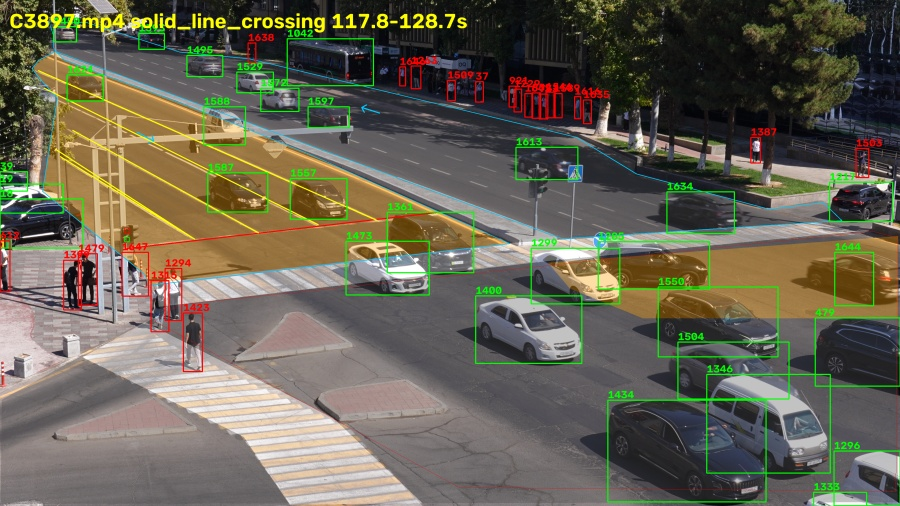

In [ ]:
from src.video import read_frame_at
import cv2
def show_event(name, ev):
    p = [v for v in VIDEOS if v.endswith(name)][0]
    raw, ctx = DEBUG[name]; s, e, lab = ev
    t = s + min(0.5, (e - s) / 2)
    frames = np.sort(ctx.df.frame.unique())
    f0 = frames[min(np.searchsorted(frames, int(t * 29.97)), len(frames) - 1)]
    img = ctx.scene.draw(read_frame_at(p, f0 / 29.97))
    for r in ctx.df[ctx.df.frame == f0].itertuples():
        col = (0, 0, 255) if r.cls == 0 else (0, 255, 0)
        cv2.rectangle(img, (int(r.x1), int(r.y1)), (int(r.x2), int(r.y2)), col, 4)
        cv2.putText(img, str(r.tid), (int(r.x1), int(r.y1) - 8), cv2.FONT_HERSHEY_SIMPLEX, 1.5, col, 3)
    cv2.putText(img, f"{name} {lab} {s:.1f}-{e:.1f}s", (40, 120), cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 255), 6)
    cb.show(img, width=900)

for name in ["C3896.mp4", "C3897.mp4"]:
    for ev in [e for e in preds["videos"][name]["events"] if e[2] == "solid_line_crossing"][:3]:
        show_event(name, ev)

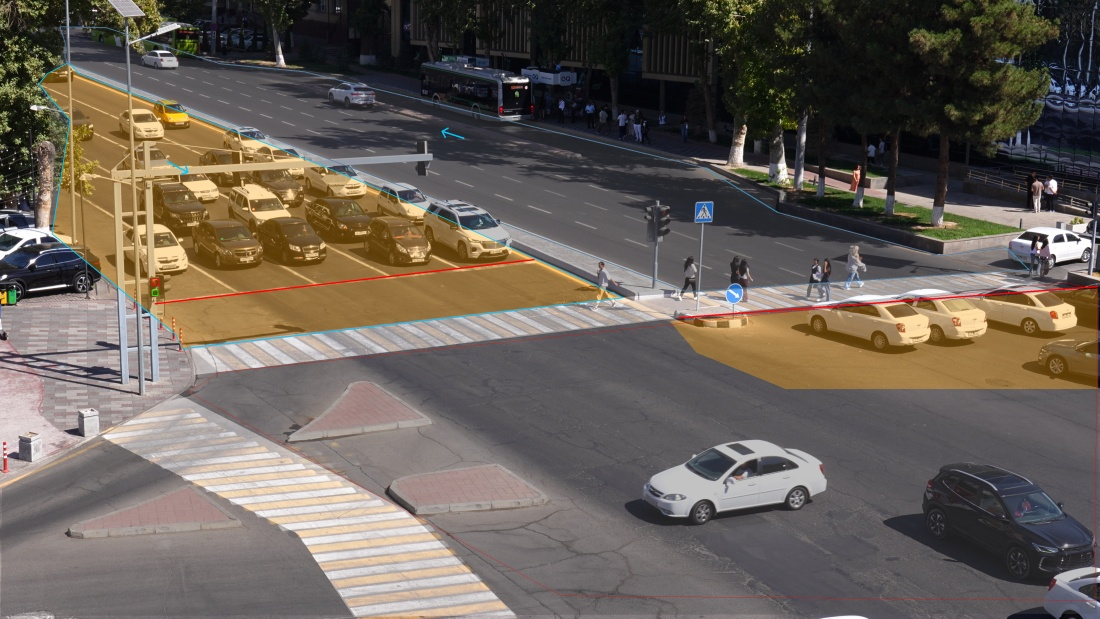

In [ ]:
rom src.video import read_frame_at
ref = read_frame_at(VIDEOS[0], 10.0)
cv2.imwrite(str(config.REF_FRAME_PATH), ref, [cv2.IMWRITE_JPEG_QUALITY, 92])
shutil.copy(config.REF_FRAME_PATH, f"{DRIVE_ROOT}/ref_frame.jpg")
Q2  = [[2338, 1121], [3831, 1007], [3831, 1357], [2742, 1357], [2431, 1230]]
SL2 = [[2369, 1109], [3831, 1000]]
scene["queue_zones"] = [scene["lanes"][0]["polygon"], Q2]
scene["stop_lines"] = scene["stop_lines"][:1] + [{"name": "stop_2", "line": SL2,
    "direction": scene["lanes"][1]["direction"], "signal": "sig_1", "intersection": scene["lanes"][1]["polygon"]}]
save_scene()

INFO:wiut.scene:C3896.mp4: scene alignment 904 inliers, max shift 5.8 px


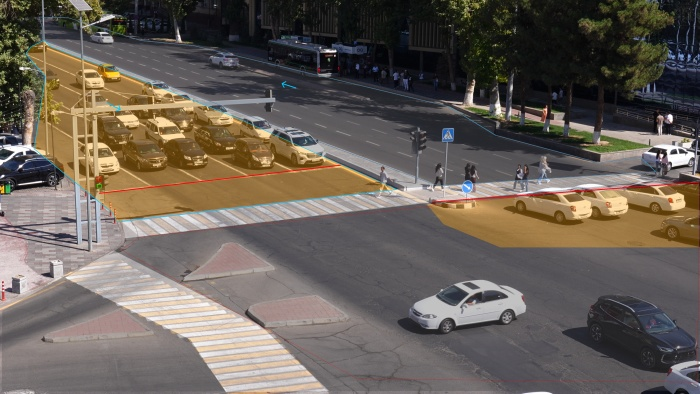

INFO:wiut.scene:C3897.mp4: scene alignment 1140 inliers, max shift 5.9 px


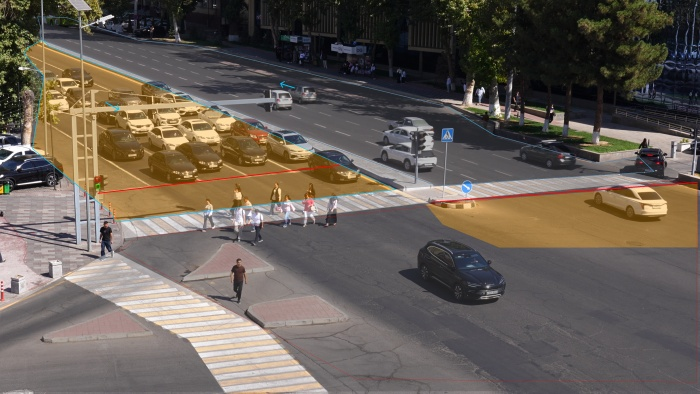

INFO:wiut.scene:C3902.mp4: scene alignment 78 inliers, max shift 131.9 px


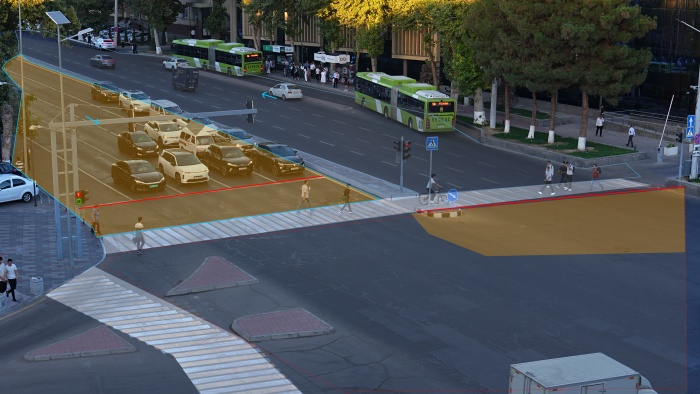

INFO:wiut.scene:C3905.mp4: scene alignment 94 inliers, max shift 75.5 px


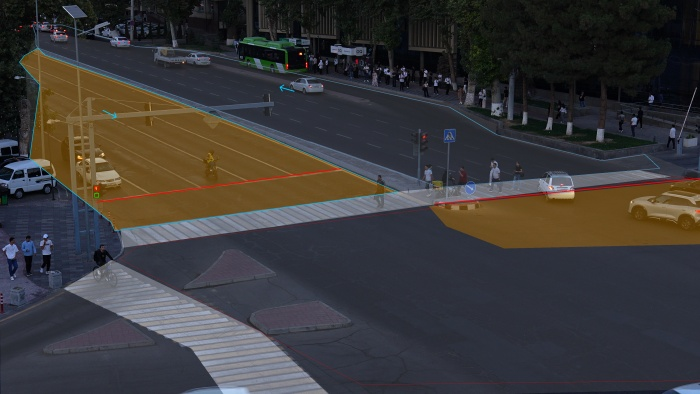

In [ ]:
from src.scene import load_scene
for p in VIDEOS:
    cb.show(load_scene(3840, 2160, video_path=p).draw(read_frame_at(p, 10.0)), width=700)

## 8 · Predictions on the sample videos (`predictions_samples.json`)

Uses the cached tracks, so it takes ~3 min on CPU. Part B is skipped here (`--no-risk`): the samples contain no
accidents, so Part B is not scored on them, and a full Part B pass takes > 1 h on Colab's 2 CPU cores.
The official full run (Part A + B within 3× video length) needs the judges' 8-core machine.

In [ ]:
!env -u WIUT_CACHE python run_submission.py --videos /content/samples/C3905.mp4 --out /content/t.json --team WannaCry
import json; print(json.load(open("/content/t.json"))["log"])

[C3905.mp4] 127.6s @ 29.97 fps, budget 383s
[C3905.mp4] 0 events, 0 risk samples, 384.3s — 1 problem(s)
   ! over time budget (384.3s > 383s): scored as empty
wrote /content/t.json
{'C3905.mp4': {'duration': 127.63, 'budget_sec': 382.9, 'errors': ['over time budget (384.3s > 383s): scored as empty'], 'part_a_sec': 253.2, 'part_b_sec': 131.2, 'total_sec': 384.3}}


In [ ]:
# Determinism: a second run must give the same JSON (up to float noise)
!env -u WIUT_CACHE python run_submission.py --videos {LOCAL_SAMPLES} --out /content/pred_run2.json --team {TEAM}
import numpy as np
a, b = json.load(open("predictions_samples.json")), json.load(open("/content/pred_run2.json"))
for k in a["videos"]:
    same_ev = a["videos"][k]["events"] == b["videos"][k]["events"]
    ra, rb = np.array(a["videos"][k]["risk"]), np.array(b["videos"][k]["risk"])
    print(k, "events identical:", same_ev, "| max risk diff:", float(np.abs(ra - rb).max()) if len(ra) else 0)

## 9 · Website material and demo test

Annotated videos at 10 fps (boxes, IDs, scene map, event banners), from cached tracks, CPU is fine (~40–60 min).
They are copied to `WIUT_CV/outputs/render/` on Drive.

In [ ]:
# Try the live demo from Colab (public *.gradio.live link, CPU settings). Stop the cell to end it.
!pip install -q gradio
!WIUT_DEMO=1 GRADIO_SHARE=True python demo/app.py

## 10 · Save and push

In [ ]:
# scene map, flow map, labels and predictions belong in the repo; videos and cache do not (.gitignore)
!git status --short
# from google.colab import userdata
# token = userdata.get("GH_TOKEN")
# !git config user.name "{ME}" && git config user.email "{ME}@team"
# !git add -A && git commit -m "scene map + labels + predictions" && git push https://{token}@github.com/yelmuratov/Traffic-event-detection-CV-WIUT.git HEAD:main

In [ ]:
!pip install -q av PyNvVideoCodec
import av, time, subprocess, os
vid = VIDEOS[3]

# A) PyAV, all CPU cores
c = av.open(vid); s = c.streams.video[0]; s.thread_type = "AUTO"
t = time.time(); n = 0
for f in c.decode(s):
    n += 1
    if n >= 300: break
print(f"A) PyAV multithread decode: {n/(time.time()-t):6.1f} fps")

# B) PyAV, skip non-reference frames
c = av.open(vid); s = c.streams.video[0]; s.thread_type = "AUTO"; s.codec_context.skip_frame = "NONREF"
t = time.time(); n = 0; last = 0
for f in c.decode(s):
    n += 1; last = f.time
    if last >= 10: break
print(f"B) PyAV skip non-ref: {n} frames in 10 s of video, {10/(time.time()-t):5.2f}x realtime speed")

# C) ffmpeg on GPU with the NVIDIA library path
t = time.time()
r = subprocess.run(f"LD_LIBRARY_PATH=/usr/lib64-nvidia ffmpeg -v error -hwaccel cuda -t 10 -i {vid} -f null -",
                   shell=True, capture_output=True, text=True)
print(f"C) ffmpeg GPU: {300/(time.time()-t):6.1f} fps", r.stderr[:200])

# D) NVIDIA PyNvVideoCodec (GPU decoder)
try:
    import PyNvVideoCodec as nvc
    dmx = nvc.CreateDemuxer(filename=vid)
    dec = nvc.CreateDecoder(gpuid=0, codec=dmx.GetNvCodecId(), cudacontext=0, cudastream=0, usedevicememory=True)
    t = time.time(); n = 0
    for pkt in dmx:
        for fr in dec.Decode(pkt):
            n += 1
        if n >= 300: break
    print(f"D) PyNvVideoCodec GPU: {n/(time.time()-t):6.1f} fps")
except Exception as e:
    print("D) PyNvVideoCodec failed:", str(e)[:200])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 32.6 MB/s eta 0:00:00
A) PyAV multithread decode:   10.3 fps
B) PyAV skip non-ref: 101 frames in 10 s of video,  0.55x realtime speed
C) ffmpeg GPU:  358.5 fps [AVHWDeviceContext @ 0x57d79ccbd700] Cannot load libcuda.so.1
[AVHWDeviceContext @ 0x57d79ccbd700] Could not dynamically load CUDA
Device creation failed: -1.
No device available for decoder: device t
D) PyNvVideoCodec failed: Failed to load NVENC library: libnvidia-encode.so.1: cannot open shared object file: No such file or directory

=== TROUBLESHOOTING STEPS ===

The NVENC library could not be found. This usually means:


In [ ]:
!git pull
!pip install -q av
import os, time, cv2
os.environ.pop("WIUT_CACHE", None); reload_all()          # no cache = real timing
from src.pipeline import detect_events
from solution import RiskEstimator
vid = VIDEOS[3]; m = probe(vid)
t0 = time.time(); ev = detect_events(vid); ta = time.time() - t0
est = RiskEstimator(); est.reset({"fps": m.fps, "width": m.width, "height": m.height, "n_frames": m.n_frames, "video_id": m.name})
cap = cv2.VideoCapture(vid); t0 = time.time(); i = 0
while True:
    ok, f = cap.read()
    if not ok: break
    est.step(f, i / m.fps); i += 1
tb = time.time() - t0
print(f"Part A {ta/m.duration:.2f}x | Part B {tb/m.duration:.2f}x | total {(ta+tb)/m.duration:.2f}x (limit 3.0x)")
os.environ["WIUT_CACHE"] = f"{DRIVE_ROOT}/cache"; reload_all()

In [ ]:
from tools.synth import reverse_clip, obstacle_clip
from src.pipeline import detect_events
rv = reverse_clip(VIDEOS[0], 150, 12, "/content/synth/rev.mp4")
ob = obstacle_clip(VIDEOS[0], 60, 60, "/content/synth/obs.mp4")
for p in [rv, ob]:
    print(os.path.basename(p), detect_events(p))

In [ ]:
import pickle, gzip, cv2
from src.pipeline import analyse, detect_events
from src.scene import _H_CACHE
from src.video import read_frame_at

def jpg(f, w=1280):
    s = w / f.shape[1]
    return cv2.imencode(".jpg", cv2.resize(f, None, fx=s, fy=s), [cv2.IMWRITE_JPEG_QUALITY, 80])[1].tobytes()

bundle = {"labels": labels, "scene": open("scene/scene_map.json").read(), "videos": {}}
for p in VIDEOS:
    meta, ctx = analyse(p)
    ev = detect_events(p)
    tracks, signals = __import__("src.tracker", fromlist=["x"]).analyse_video(meta, ctx.scene)
    signals = {k: v for k, v in signals.items() if k != "__thumbs__"}
    times = sorted({round((s + e) / 2, 1) for s, e, _ in labels[meta.name]["events"] + ev} | set(range(0, int(meta.duration), 10)))
    frames = {t: jpg(f) for t in times if (f := read_frame_at(p, t)) is not None}
    bundle["videos"][meta.name] = {"meta": meta.to_dict(), "tracks": tracks, "signals": signals,
                                   "H": _H_CACHE.get(p), "pred": ev, "frames": frames}
    print(meta.name, len(tracks), len(frames), "frames")
with gzip.open(f"{DRIVE_ROOT}/dev_bundle.pkl.gz", "wb") as f:
    pickle.dump(bundle, f)
print("saved", os.path.getsize(f"{DRIVE_ROOT}/dev_bundle.pkl.gz") // 2**20, "MB")

INFO:wiut.pipeline:C3896.mp4: 30 events (104 raw) in 11.7s


C3896.mp4 158094 86 frames


INFO:wiut.pipeline:C3897.mp4: 46 events (127 raw) in 12.0s


C3897.mp4 151647 96 frames


INFO:wiut.pipeline:C3902.mp4: 28 events (113 raw) in 14.3s


C3902.mp4 179688 79 frames


INFO:wiut.pipeline:C3905.mp4: 24 events (60 raw) in 6.7s


C3905.mp4 69473 46 frames
saved 69 MB


In [ ]:
import av, cv2, time, numpy as np
p = "/content/samples/C3905.mp4"
T = 30.0  # seconds of video to read

def pyav(interp=None, scale=True):
    t0 = time.time(); n = 0
    with av.open(p) as c:
        st = c.streams.video[0]; st.thread_type = "AUTO"; st.codec_context.skip_frame = "NONREF"
        for f in c.decode(st):
            if f.time > T: break
            if scale:
                kw = {"interpolation": interp} if interp else {}
                img = f.to_ndarray(format="bgr24", width=1280, height=720, **kw)
            else:
                img = f.to_ndarray(format="bgr24")[::3, ::3]
            n += 1
    return time.time() - t0, n

def ocv():
    t0 = time.time(); n = 0; cap = cv2.VideoCapture(p); i = 0
    while cap.get(cv2.CAP_PROP_POS_MSEC) < T * 1000:
        if i % 3 == 0:
            ok, img = cap.read(); img = img[::3, ::3]; n += 1
        else:
            ok = cap.grab()
        if not ok: break
        i += 1
    return time.time() - t0, n

for name, fn in [("pyav bicubic (now)", lambda: pyav()),
                 ("pyav fast_bilinear", lambda: pyav("FAST_BILINEAR")),
                 ("pyav no-scale+slice", lambda: pyav(scale=False)),
                 ("opencv every 3rd", ocv)]:
    dt, n = fn()
    print(f"{name:22s} {dt:5.1f}s for {T:.0f}s video = {dt/T:.2f}x  ({n} frames)")

pyav bicubic (now)      49.6s for 30s video = 1.65x  (300 frames)
pyav fast_bilinear      45.2s for 30s video = 1.51x  (300 frames)
pyav no-scale+slice     52.3s for 30s video = 1.74x  (300 frames)
opencv every 3rd        79.2s for 30s video = 2.64x  (301 frames)


In [ ]:
%%writefile /content/bench.py
import av, cv2, time
p = "/content/samples/C3905.mp4"; T = 30.0; FPS = 29.97; N = int(T * FPS)

def pyav(skip, interp="FAST_BILINEAR"):
    t0 = time.time(); n = 0
    with av.open(p) as c:
        st = c.streams.video[0]; st.thread_type = "AUTO"
        if skip: st.codec_context.skip_frame = "NONREF"
        for i, f in enumerate(c.decode(st)):
            if f.time > T: break
            if skip or i % 3 == 0:
                f.to_ndarray(format="bgr24", width=1280, height=720, interpolation=interp); n += 1
    return time.time() - t0, n

def ocv(stride):
    t0 = time.time(); n = 0; cap = cv2.VideoCapture(p)
    for i in range(N):
        if i % stride == 0:
            ok, img = cap.read(); img = cv2.resize(img, (1280, 720), interpolation=cv2.INTER_LINEAR); n += 1
        else:
            ok = cap.grab()
        if not ok: break
    return time.time() - t0, n

for name, fn in [("opencv read every 3rd", lambda: ocv(3)),
                 ("opencv read all", lambda: ocv(1)),
                 ("pyav nonref (now)", lambda: pyav(True)),
                 ("pyav all, keep every 3rd", lambda: pyav(False))]:
    dt, n = fn()
    print(f"{name:26s} {dt:5.1f}s for {T:.0f}s video = {dt/T:.2f}x  ({n} frames)", flush=True)

Writing /content/bench.py


In [ ]:
   !git pull -q && for d in pyav_ref opencv; do python -m tools.profile /content/samples/C3905.mp4 --decoder $d 2>&1 | grep -v Warning; done

cpu cores 2, torch threads 1, decoder pyav_ref, max_width 1280
pure decode: 48.4s for 30s of video = 1.61x (300 frames)
wiut.scene: C3905.mp4: scene alignment 94 inliers, max shift 75.5 px
wiut.pipeline: C3905.mp4: scene alignment 16.8s
wiut.tracker: C3905.mp4 analysed in 230.8s (1.81x realtime); 1275 frames; time split: decode 164s, model 64s, signals 0s, thumbs 0s
wiut.pipeline: C3905.mp4: rules 4.3s
wiut.pipeline: C3905.mp4: 13 events (32 raw) in 254.0s
detect_events: 254s = 1.99x realtime, 13 events
Exception ignored in: <generator object iter_frames_fast at 0x79f02a56b220>
Traceback (most recent call last):
  File "/content/Traffic-event-detection-CV-WIUT/src/video.py", line 169, in iter_frames_fast
TypeError: catching classes that do not inherit from BaseException is not allowed
cpu cores 2, torch threads 1, decoder opencv, max_width 1280
pure decode: 80.9s for 30s of video = 2.70x (300 frames)
wiut.scene: C3905.mp4: scene alignment 94 inliers, max shift 75.5 px
wiut.pipeline: C3

In [ ]:
!python /content/bench.py

opencv read every 3rd       81.6s for 30s video = 2.72x  (300 frames)
opencv read all             98.0s for 30s video = 3.27x  (899 frames)
pyav nonref (now)           45.2s for 30s video = 1.51x  (300 frames)
pyav all, keep every 3rd    72.5s for 30s video = 2.42x  (300 frames)


In [ ]:
!git pull -q && python run_submission.py --videos /content/samples --out predictions_samples.json --team WannaCry --no-risk --time-factor 100 2>&1 | tail -8 && python evaluate.py --pred predictions_samples.json --gt my_labels.json | grep "Score A" && cp predictions_samples.json /content/drive/MyDrive/WIUT_CV/outputs/

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
!git pull -q && mkdir -p /content/render && for v in /content/samples/*.mp4; do python -m tools.render $v /content/render --pred predictions_samples.json --fps 10 2>&1 | tail -1; done && mkdir -p /content/drive/MyDrive/WIUT_CV/outputs/render && cp /content/render/* /content/drive/MyDrive/WIUT_CV/outputs/render/ && ls -la /content/drive/MyDrive/WIUT_CV/outputs/render

In [ ]:
import glob, subprocess
src = [p for p in glob.glob("/content/drive/MyDrive/WIUT_CV/samples/*") if "C3896" in p][0]
print("using", src)
out = "/content/drive/MyDrive/WIUT_CV/outputs/demo_clip_C3896.mp4"
subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-ss", "55", "-t", "40", "-i", src, "-vf", "scale=1920:-2",
                "-c:v", "libx264", "-crf", "23", "-preset", "veryfast", "-an", out], check=True)
!ls -lh {out}

using /content/drive/MyDrive/WIUT_CV/samples/C3896.MP4
-rw------- 1 root root 10M Sep 27 06:57 /content/drive/MyDrive/WIUT_CV/outputs/demo_clip_C3896.mp4
